In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
from collections import Counter
import tiktoken
import seaborn as sns
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 
from utils import train_test

# Processing data

In [ ]:
# Variable
percentage_genre_to_keep = 25


In [4]:
df = pd.read_csv("./data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)


In [5]:
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
print(df_filtered_one_genre.shape)
df_filtered_one_genre.head()

(8753, 31)


,Script,Title,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,...,imdb_romance,imdb_sci-fi,imdb_short,imdb_sport,imdb_talk-show,imdb_thriller,imdb_war,imdb_western,imdb_adult,genre_count
0,So what's goin' on?\n Where's my brother?\n So...,Beyond the Dunwich Horror (2008),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,"Like this?\n Good.\n Okay, that's good.\n Righ...",Beyond the Gates (2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1\n Beyond the hills\n Stay there!\n Voichita!...,Beyond the Hills (2012),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
23,"Sir, this place is so dusty.\n Hmm.\n Your cho...",Bhagavan Dasante Ramrajyam (2023),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
28,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",Bhairathi Ranagal (2024),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [6]:
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
df_filtered_one_genre['filtered_genre']


/tmp/ipykernel_28878/707917607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


0             imdb_horror
3              imdb_drama
5              imdb_drama
23             imdb_drama
28             imdb_drama
               ...       
38115          imdb_drama
38123    imdb_documentary
38125          imdb_drama
38133      imdb_adventure
38134          imdb_drama
Name: filtered_genre, Length: 8753, dtype: object

In [7]:
df_filtered_one_genre['filtered_genre'].value_counts()


filtered_genre
imdb_drama          2948
imdb_comedy         1622
imdb_documentary    1301
imdb_horror          944
imdb_thriller        643
imdb_romance         262
imdb_action          242
imdb_western         112
imdb_family          112
imdb_sci-fi           79
imdb_crime            61
imdb_animation        56
imdb_talk-show        51
imdb_music            50
imdb_short            49
imdb_mystery          49
imdb_adventure        37
imdb_fantasy          27
imdb_reality-tv       21
imdb_musical          21
imdb_war              16
imdb_biography        16
imdb_sport            12
imdb_game-show         8
imdb_news              8
imdb_history           6
Name: count, dtype: int64

/tmp/ipykernel_28878/3269823211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")


Text(0, 0.5, 'Genres')

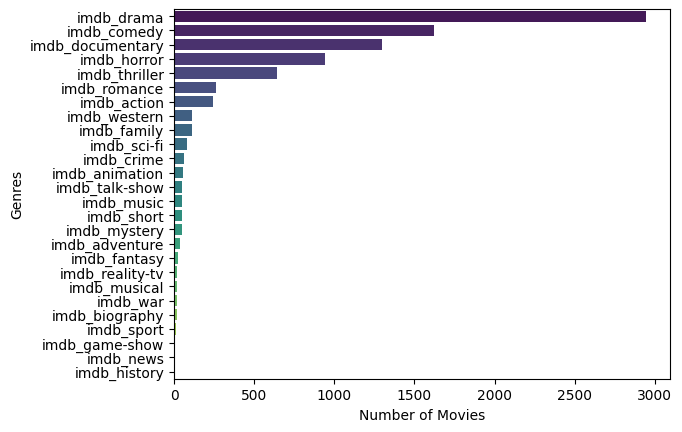

In [8]:

df_counts = df_filtered_one_genre['filtered_genre'].value_counts().reset_index()
df_counts.columns = ['Genre', 'Count']

sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")

plt.xlabel('Number of Movies')
plt.ylabel('Genres')


In [9]:
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])

In [10]:
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

for genre,number in sorted_list:
    print(f"Genre: {genre}, number of samples: {number}")

genre_to_keep = [genre for genre,_ in sorted_list]
genre_to_keep

Genre: imdb_drama, number of samples: 2948
Genre: imdb_comedy, number of samples: 1622
Genre: imdb_documentary, number of samples: 1301
Genre: imdb_horror, number of samples: 944
Genre: imdb_thriller, number of samples: 643
Genre: imdb_romance, number of samples: 262


['imdb_drama',
 'imdb_comedy',
 'imdb_documentary',
 'imdb_horror',
 'imdb_thriller',
 'imdb_romance']

In [11]:
columns_to_keep = ['Script','filtered_genre']

df_filtered_one_genre_to_train = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_filtered_one_genre_to_train = df_filtered_one_genre_to_train[columns_to_keep].reset_index(drop=True)
df_filtered_one_genre_to_train

,Script,filtered_genre
0,So what's goin' on?\n Where's my brother?\n So...,imdb_horror
1,"Like this?\n Good.\n Okay, that's good.\n Righ...",imdb_drama
2,1\n Beyond the hills\n Stay there!\n Voichita!...,imdb_drama
3,"Sir, this place is so dusty.\n Hmm.\n Your cho...",imdb_drama
4,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",imdb_drama
...,...,...
7715,"Here in Malaysia, there is an almost\n overwhe...",imdb_comedy
7716,"Okay, let's go for a take\n Get ready to carry...",imdb_drama
7717,Turn left.\n Make a right.\n Is this the kitch...,imdb_documentary
7718,Are you going somewhere? No?\n Last week I was...,imdb_drama


# Training and test

In [12]:
def lemma_tokenize(doc):
    wnl = WordNetLemmatizer()
    return [wnl.lemmatize(t) for t in word_tokenize(doc)]

def char_tokenize(doc):
    return [char for char in doc]

def byte_tokenize(doc):
    tokens = doc.encode("utf-8")
    tokens = list(map(int, tokens))
    return [str(token) for token in tokens]

def gpt_tokenize(doc):
    enc = tiktoken.encoding_for_model("gpt-4")
    tokens = enc.encode(doc)
    return [str(token) for token in tokens]

Model: MultinomialNB with unigram
Features dimension: (6176, 200664)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.66      0.58       314
imdb_documentary       0.89      0.82      0.85       251
      imdb_drama       0.65      0.72      0.69       609
     imdb_horror       0.65      0.56      0.60       171
    imdb_romance       0.84      0.26      0.40        61
   imdb_thriller       0.62      0.36      0.46       138

        accuracy                           0.66      1544
       macro avg       0.70      0.56      0.60      1544
    weighted avg       0.67      0.66      0.65      1544

Top 15 mots pour la classe 'imdb_comedy': ['on' 'this' 'my' 'me' 'we' 'in' 'what' 'of' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'he' 'they' 'this' 'we' 'is' 'was' 'in' 'that' 'it' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la classe 'imdb_drama': ['for' 

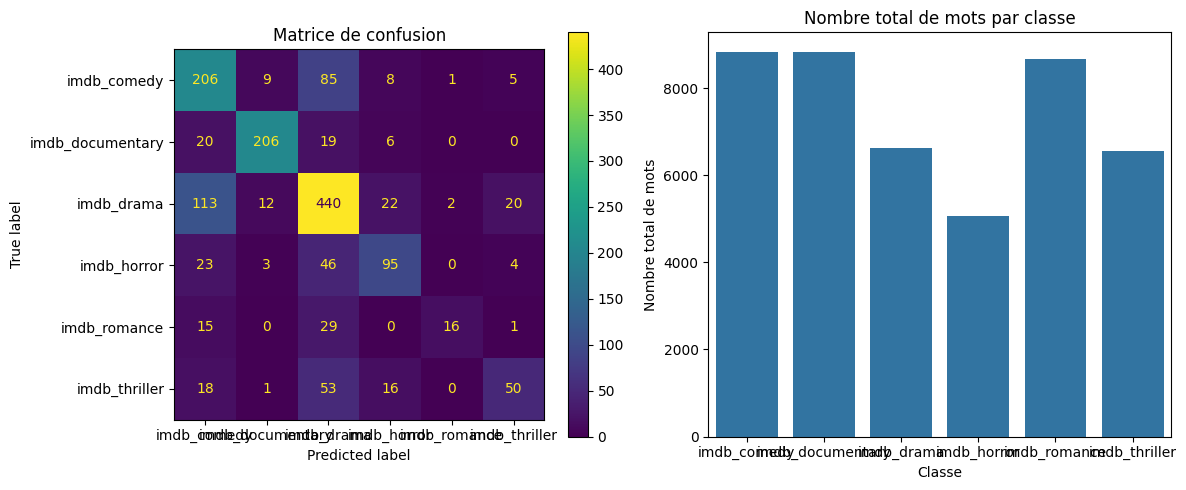

In [13]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigram")


Model: MultinomialNB with unigram
Features dimension: (1257, 88005)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.46      0.60      0.52        55
imdb_documentary       0.88      0.82      0.84        60
      imdb_drama       0.43      0.33      0.38        60
     imdb_horror       0.78      0.61      0.68        51
    imdb_romance       0.57      0.86      0.69        42
   imdb_thriller       0.59      0.49      0.53        47

        accuracy                           0.61       315
       macro avg       0.62      0.62      0.61       315
    weighted avg       0.62      0.61      0.61       315

Top 15 mots pour la classe 'imdb_comedy': ['on' 'my' 'this' 'me' 'we' 'in' 'what' 'is' 'of' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['he' 'for' 'they' 'this' 'is' 'we' 'was' 'in' 'it' 'that' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la classe 'imdb_drama': ['for' 'th

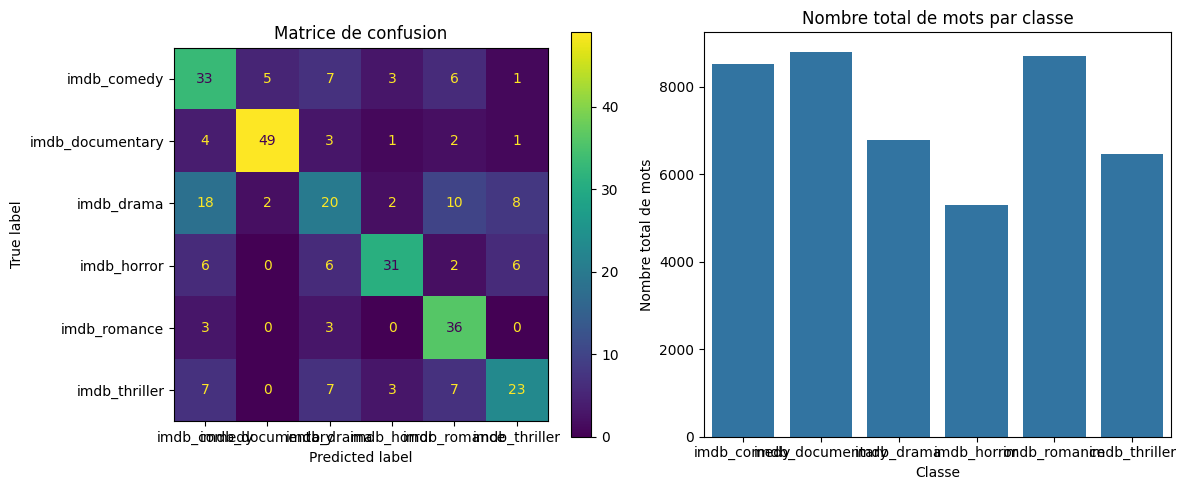

In [14]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigram",equilibrate=True)




Model: MultinomialNB with unigram and bigram
Features dimension: (6176, 6042430)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.77      0.43      0.55       314
imdb_documentary       0.93      0.79      0.86       251
      imdb_drama       0.51      0.97      0.67       609
     imdb_horror       1.00      0.02      0.03       171
    imdb_romance       0.00      0.00      0.00        61
   imdb_thriller       0.00      0.00      0.00       138

        accuracy                           0.60      1544
       macro avg       0.54      0.37      0.35      1544
    weighted avg       0.62      0.60      0.52      1544



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Top 15 mots pour la classe 'imdb_comedy': ['on' 'this' 'my' 'me' 'we' 'in' 'what' 'of' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'he' 'they' 'this' 'we' 'is' 'was' 'in' 'that' 'it' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la classe 'imdb_drama': ['for' 'this' 'my' 'we' 'in' 'is' 'me' 'of' 'what' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_horror': ['on' 'no' 'in' 'this' 'me' 'is' 'of' 'we' 'what' 'and' 'that' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_romance': ['my' 'for' 'in' 'this' 'we' 'me' 'of' 'what' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_thriller': ['no' 'my' 'this' 'in' 'we' 'of' 'is' 'me' 'what' 'and' 'that' 'it' 'to'
 'the' 'you']


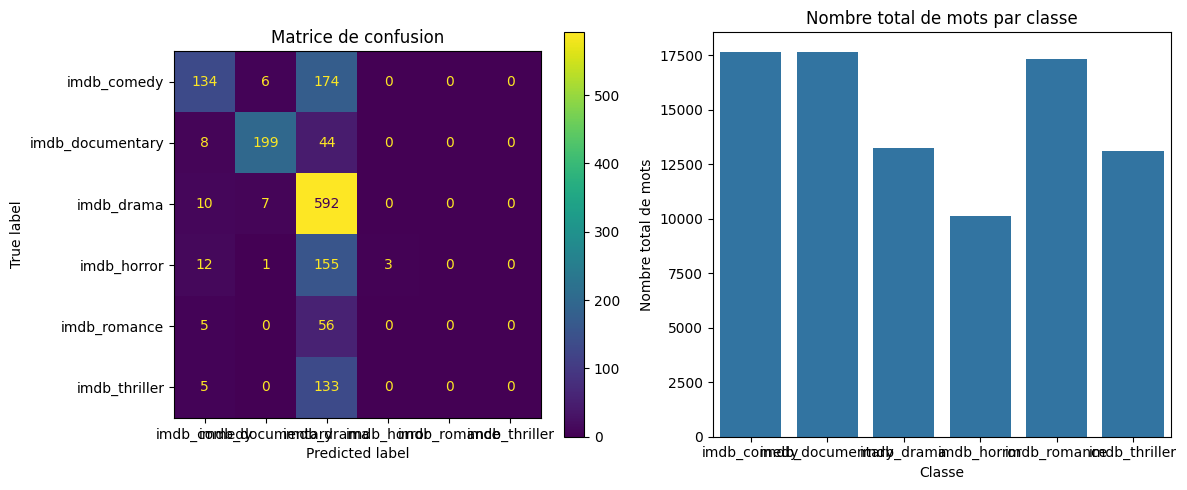

In [15]:
model = make_pipeline(CountVectorizer(ngram_range = (1,2)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigram and bigram")


Model: MultinomialNB with unigram and bigram
Features dimension: (1257, 1914042)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.31      0.69      0.43        55
imdb_documentary       0.90      0.77      0.83        60
      imdb_drama       0.00      0.00      0.00        60
     imdb_horror       1.00      0.08      0.15        51
    imdb_romance       0.36      1.00      0.53        42
   imdb_thriller       0.33      0.13      0.18        47

        accuracy                           0.43       315
       macro avg       0.48      0.44      0.35       315
    weighted avg       0.49      0.43      0.35       315

Top 15 mots pour la classe 'imdb_comedy': ['no' 'my' 'this' 'me' 'we' 'in' 'what' 'of' 'is' 'and' 'that' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'he' 'they' 'this' 'we' 'is' 'was' 'in' 'it' 'that' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la classe 'imdb_drama

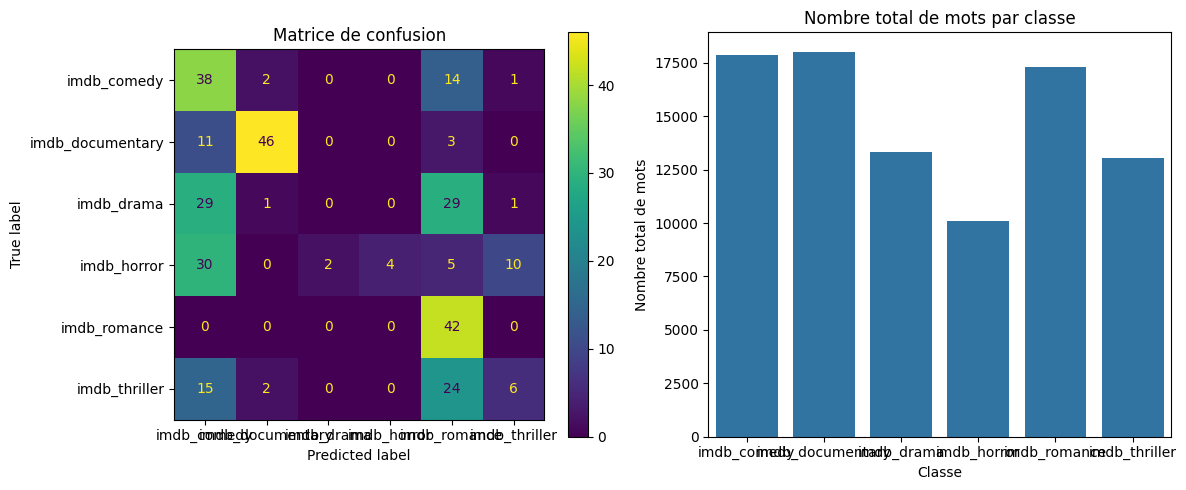

In [16]:
model = make_pipeline(CountVectorizer(ngram_range = (1,2)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigram and bigram",equilibrate=True)


Model: MultinomialNB with bigram
Features dimension: (6176, 5841766)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.87      0.33      0.48       314
imdb_documentary       0.93      0.78      0.85       251
      imdb_drama       0.49      0.98      0.66       609
     imdb_horror       1.00      0.01      0.02       171
    imdb_romance       0.00      0.00      0.00        61
   imdb_thriller       0.00      0.00      0.00       138

        accuracy                           0.58      1544
       macro avg       0.55      0.35      0.33      1544
    weighted avg       0.63      0.58      0.50      1544



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Top 15 mots pour la classe 'imdb_comedy': ['thank you' 'you can' 'all right' 'to the' 'to be' 'if you' 'of the'
 'come on' 'we re' 'this is' 'do you' 'in the' 'are you' 'you know'
 'you re']
Top 15 mots pour la classe 'imdb_documentary': ['they re' 'he was' 'at the' 'going to' 'we re' 'and the' 'this is'
 'you re' 'on the' 'to the' 'to be' 'it was' 'you know' 'in the' 'of the']
Top 15 mots pour la classe 'imdb_drama': ['to the' 'thank you' 'have to' 'you can' 'if you' 'of the' 'to be'
 'this is' 'come on' 'want to' 'in the' 'you know' 'do you' 'are you'
 'you re']
Top 15 mots pour la classe 'imdb_horror': ['to the' 'to be' 'have to' 'don know' 'all right' 'of the' 'no no'
 'this is' 'we re' 'come on' 'you know' 'do you' 'in the' 'are you'
 'you re']
Top 15 mots pour la classe 'imdb_romance': ['no no' 'of the' 'going to' 'we re' 'have to' 'if you' 'want to' 'to be'
 'this is' 'in the' 'do you' 'thank you' 'are you' 'you know' 'you re']
Top 15 mots pour la classe 'imdb_thriller': ['all r

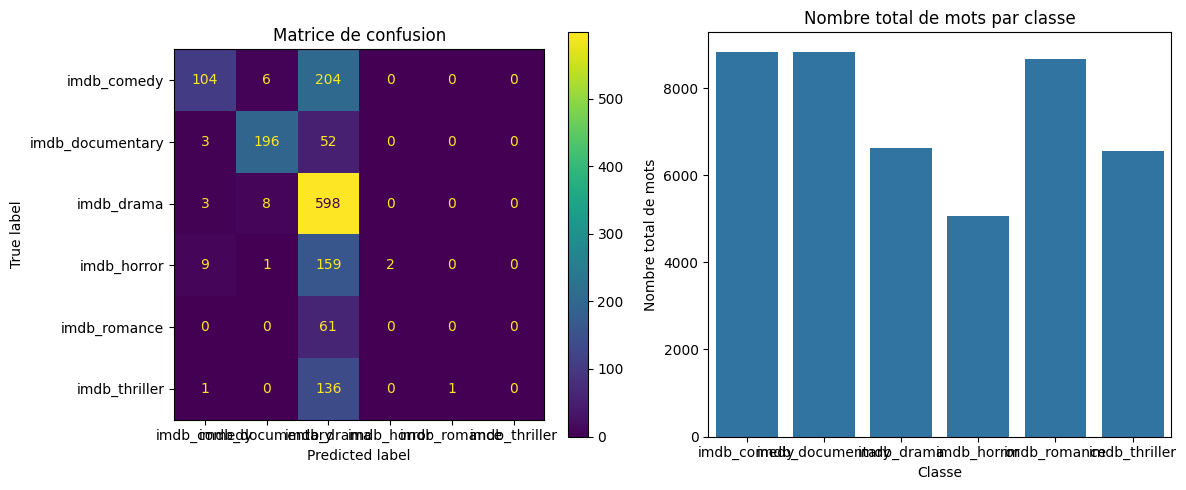

In [17]:
model = make_pipeline(CountVectorizer(ngram_range = (2,2)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with bigram")



Model: MultinomialNB with bigram
Features dimension: (1257, 1857432)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.37      0.73      0.49        55
imdb_documentary       1.00      0.80      0.89        60
      imdb_drama       1.00      0.07      0.12        60
     imdb_horror       1.00      0.06      0.11        51
    imdb_romance       0.29      0.93      0.44        42
   imdb_thriller       0.44      0.17      0.25        47

        accuracy                           0.45       315
       macro avg       0.68      0.46      0.38       315
    weighted avg       0.71      0.45      0.39       315

Top 15 mots pour la classe 'imdb_comedy': ['have to' 'on the' 'you can' 'to be' 'to the' 'if you' 'of the' 'come on'
 'we re' 'this is' 'do you' 'in the' 'you know' 'are you' 'you re']
Top 15 mots pour la classe 'imdb_documentary': ['he was' 'they re' 'at the' 'going to' 'we re' 'and the' 'you re'
 'this is' 'on t

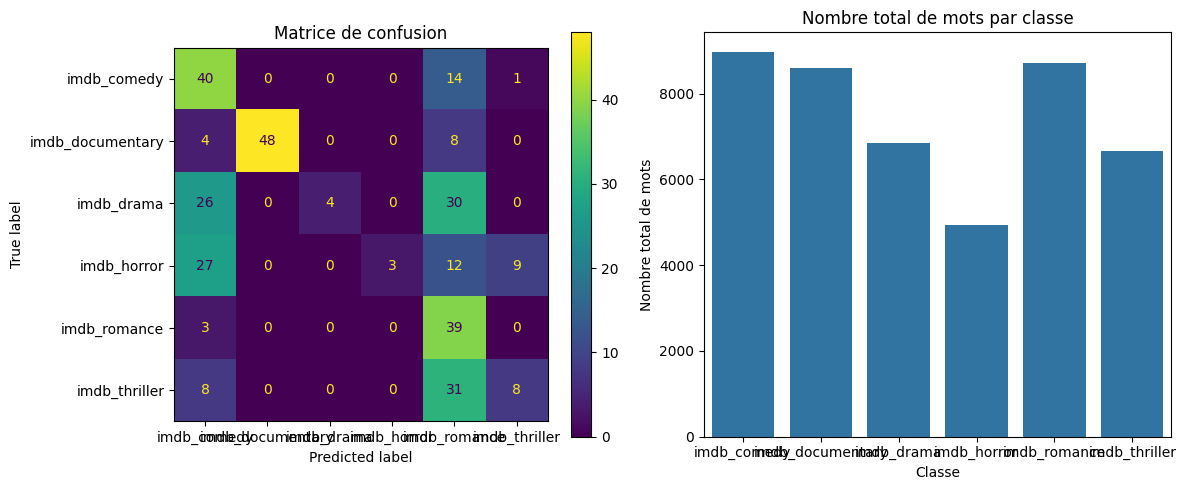

In [18]:
model = make_pipeline(CountVectorizer(ngram_range = (2,2)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with bigram",equilibrate=True)


/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Model: MultinomialNB with unigranne and stop words in english
Features dimension: (6176, 200363)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.66      0.58       314
imdb_documentary       0.89      0.80      0.84       251
      imdb_drama       0.66      0.73      0.69       609
     imdb_horror       0.62      0.56      0.59       171
    imdb_romance       0.84      0.26      0.40        61
   imdb_thriller       0.67      0.36      0.47       138

        accuracy                           0.65      1544
       macro avg       0.70      0.56      0.59      1544
    weighted avg       0.67      0.65      0.65      1544

Top 15 mots pour la classe 'imdb_comedy': ['think' 'want' 've' 'let' 'good' 'got' 'okay' 'come' 'll' 'yeah' 'right'
 'oh' 'know' 'don' 'like']
Top 15 mots pour la classe 'imdb_documentary': ['come' 'good' 'said' 'want' 'yeah' 'got' 've' 'right' 'going' 'time'
 'think' 'don' 'people' '

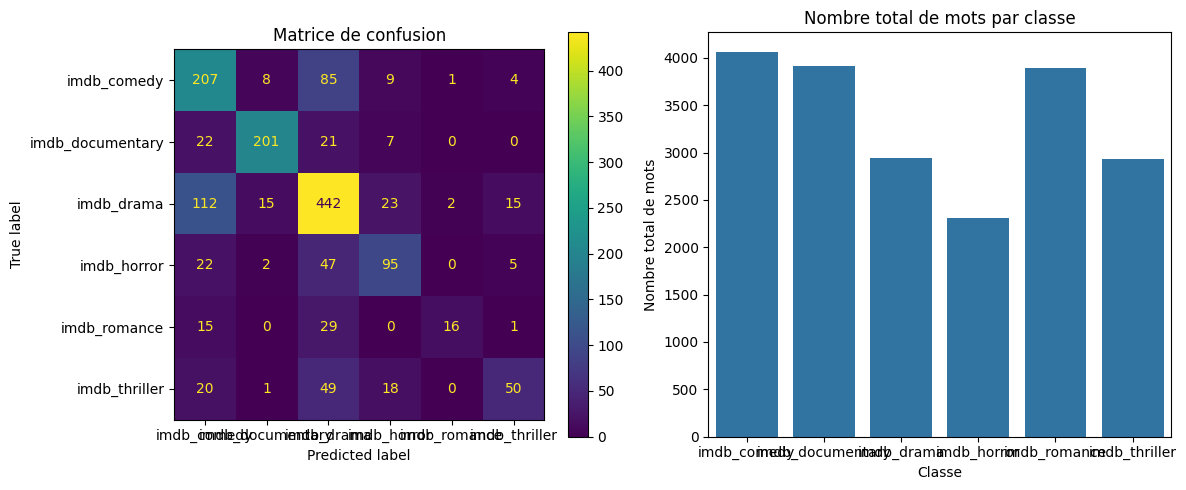

In [19]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigranne and stop words in english")



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Model: MultinomialNB with unigranne and stop words in english
Features dimension: (1257, 84074)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.54      0.69      0.60        55
imdb_documentary       0.91      0.80      0.85        60
      imdb_drama       0.48      0.50      0.49        60
     imdb_horror       0.74      0.57      0.64        51
    imdb_romance       0.55      0.74      0.63        42
   imdb_thriller       0.41      0.30      0.35        47

        accuracy                           0.60       315
       macro avg       0.61      0.60      0.59       315
    weighted avg       0.61      0.60      0.60       315

Top 15 mots pour la classe 'imdb_comedy': ['think' 've' 'want' 'let' 'good' 'got' 'okay' 'come' 'll' 'yeah' 'right'
 'oh' 'know' 'like' 'don']
Top 15 mots pour la classe 'imdb_documentary': ['way' 'come' 'good' 'want' 'got' 'yeah' 've' 'right' 'going' 'time'
 'think' 'people' 'don' 'know

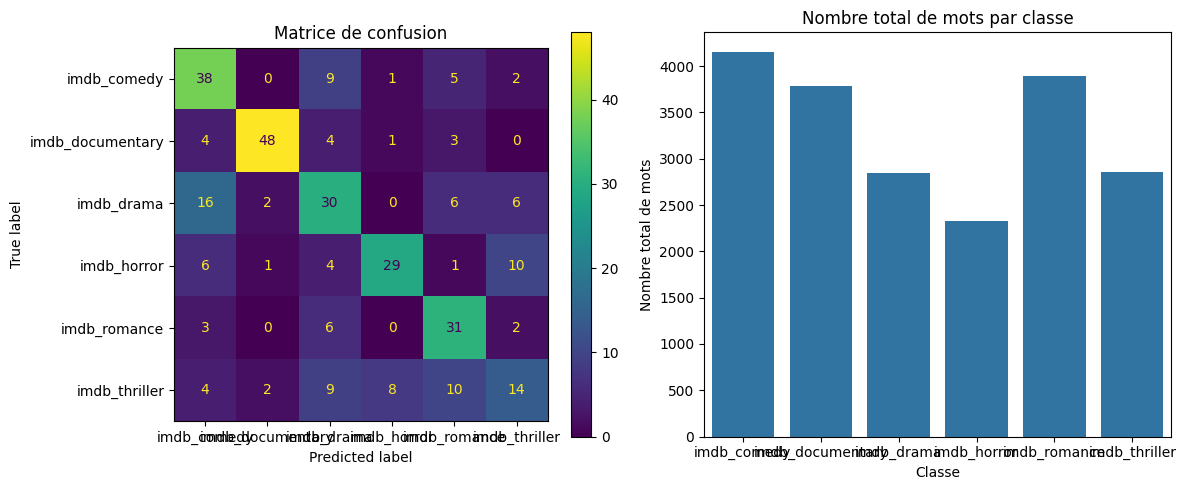

In [20]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigranne and stop words in english",equilibrate=True)



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Model: MultinomialNB with word_tokenize
Features dimension: (6176, 299686)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.51      0.58      0.54       314
imdb_documentary       0.90      0.83      0.87       251
      imdb_drama       0.60      0.73      0.66       609
     imdb_horror       0.44      0.40      0.42       171
    imdb_romance       0.33      0.02      0.03        61
   imdb_thriller       0.46      0.21      0.29       138

        accuracy                           0.60      1544
       macro avg       0.54      0.46      0.47      1544
    weighted avg       0.59      0.60      0.59      1544

Top 15 mots pour la classe 'imdb_comedy': ["n't" 'that' 'and' '!' 'it' "'s" 'a' 'to' '-' 'the' '?' 'i' 'you' ',' '.']
Top 15 mots pour la classe 'imdb_documentary': ['is' 'was' 'in' "'s" 'that' 'it' 'you' 'of' 'a' 'to' 'i' 'and' 'the' ','
 '.']
Top 15 mots pour la classe 'imdb_drama': ['that' '!' 'and' "n'

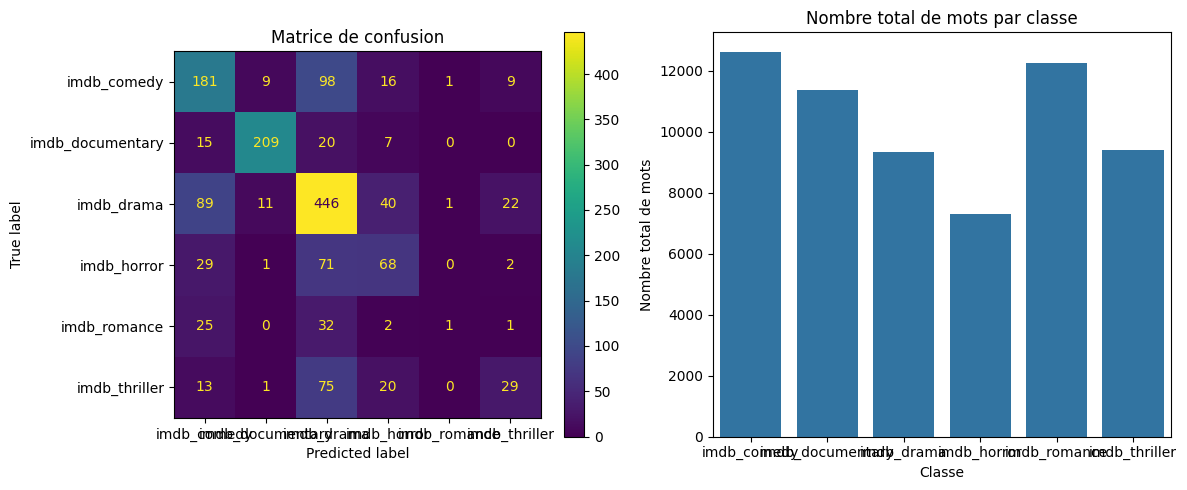

In [21]:
model = make_pipeline(CountVectorizer(tokenizer=word_tokenize), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with word_tokenize")


/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Model: MultinomialNB with word_tokenize
Features dimension: (1257, 101570)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.51      0.75      0.61        55
imdb_documentary       0.91      0.80      0.85        60
      imdb_drama       0.53      0.50      0.51        60
     imdb_horror       0.54      0.41      0.47        51
    imdb_romance       0.67      0.76      0.71        42
   imdb_thriller       0.61      0.49      0.54        47

        accuracy                           0.62       315
       macro avg       0.63      0.62      0.61       315
    weighted avg       0.63      0.62      0.62       315

Top 15 mots pour la classe 'imdb_comedy': ["n't" 'and' 'that' '!' 'it' 'a' 'to' "'s" '-' 'the' '?' 'i' 'you' ',' '.']
Top 15 mots pour la classe 'imdb_documentary': ['is' 'was' 'in' "'s" 'that' 'it' 'you' 'of' 'a' 'to' 'and' 'i' 'the' ','
 '.']
Top 15 mots pour la classe 'imdb_drama': ['do' 'that' "n't" 'and

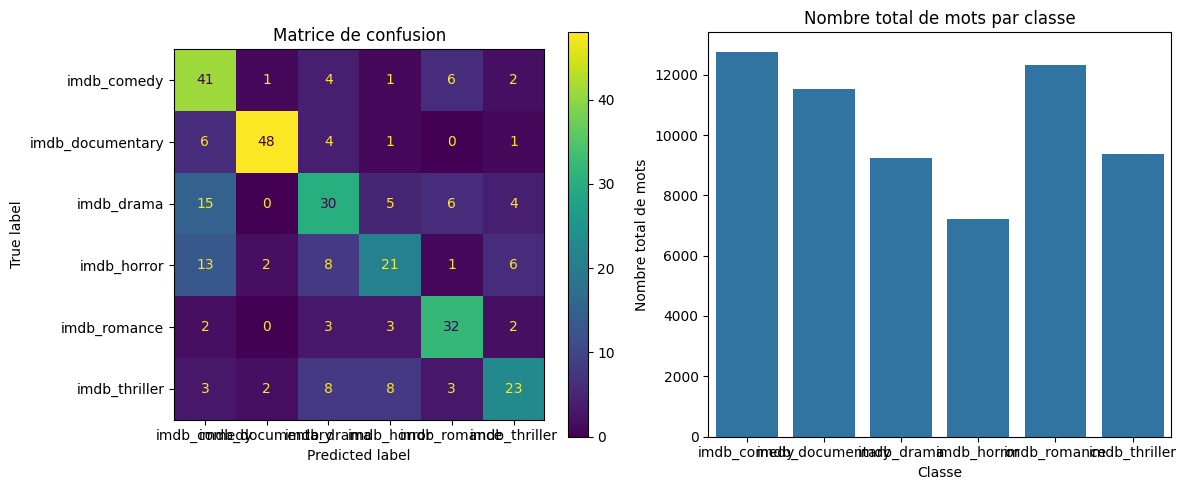

In [22]:
model = make_pipeline(CountVectorizer(tokenizer=word_tokenize), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with word_tokenize",equilibrate=True)


/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Model: MultinomialNB with lemma_tokenize
Features dimension: (6176, 285326)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.51      0.57      0.54       314
imdb_documentary       0.90      0.83      0.87       251
      imdb_drama       0.60      0.73      0.66       609
     imdb_horror       0.44      0.40      0.42       171
    imdb_romance       0.33      0.02      0.03        61
   imdb_thriller       0.45      0.21      0.29       138

        accuracy                           0.60      1544
       macro avg       0.54      0.46      0.47      1544
    weighted avg       0.59      0.60      0.59      1544

Top 15 mots pour la classe 'imdb_comedy': ["n't" 'that' 'and' '!' 'it' "'s" 'to' 'a' '-' 'the' '?' 'i' 'you' ',' '.']
Top 15 mots pour la classe 'imdb_documentary': ['is' 'wa' 'in' "'s" 'that' 'you' 'it' 'of' 'to' 'a' 'i' 'and' 'the' ','
 '.']
Top 15 mots pour la classe 'imdb_drama': ['that' '!' 'and' "n'

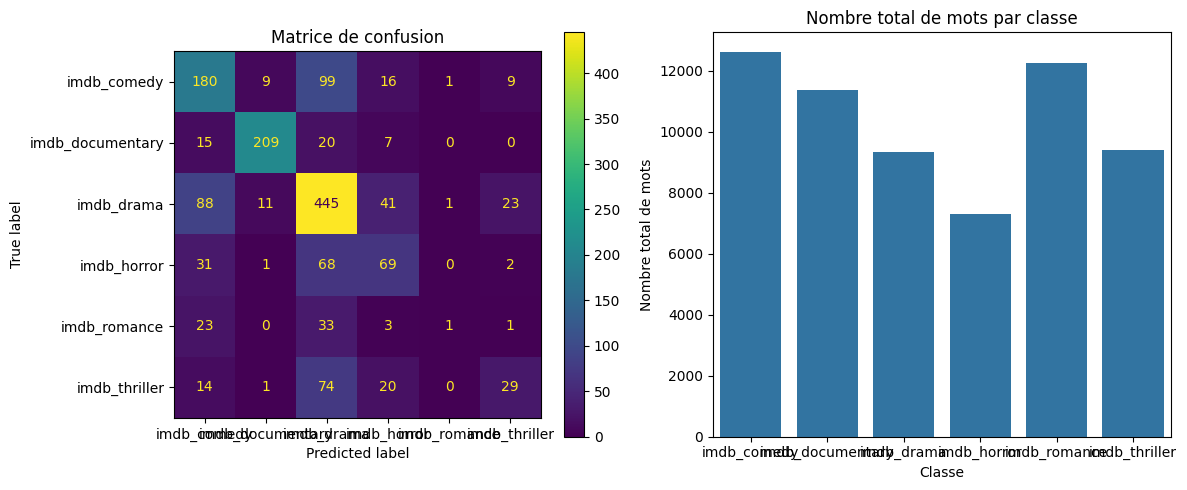

In [23]:
model = make_pipeline(CountVectorizer(tokenizer=lemma_tokenize, ngram_range = (1,1)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with lemma_tokenize")

/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Model: MultinomialNB with lemma_tokenize
Features dimension: (1257, 109102)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.57      0.71      0.63        55
imdb_documentary       0.96      0.75      0.84        60
      imdb_drama       0.48      0.50      0.49        60
     imdb_horror       0.71      0.57      0.63        51
    imdb_romance       0.58      0.71      0.64        42
   imdb_thriller       0.45      0.43      0.44        47

        accuracy                           0.61       315
       macro avg       0.62      0.61      0.61       315
    weighted avg       0.63      0.61      0.62       315

Top 15 mots pour la classe 'imdb_comedy': ["n't" 'that' 'and' '!' 'it' "'s" 'to' '-' 'a' 'the' '?' 'i' 'you' ',' '.']
Top 15 mots pour la classe 'imdb_documentary': ['is' 'wa' 'in' "'s" 'you' 'that' 'it' 'of' 'i' 'to' 'a' 'and' 'the' ','
 '.']
Top 15 mots pour la classe 'imdb_drama': ['do' 'and' '!' "n't" '

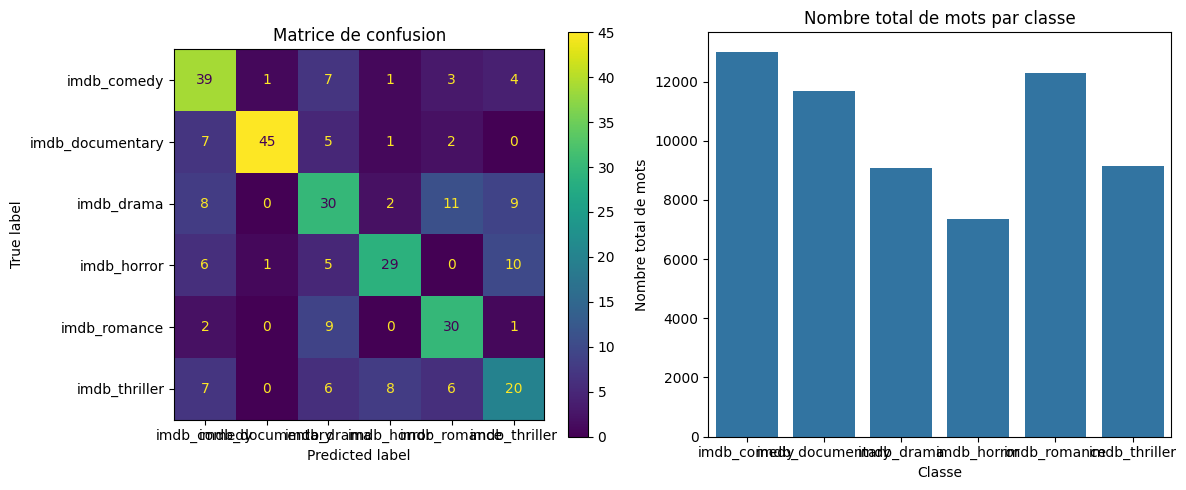

In [24]:
model = make_pipeline(CountVectorizer(tokenizer=lemma_tokenize, ngram_range = (1,1)), MultinomialNB())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with lemma_tokenize",equilibrate=True)

Model: MultinomialNB with unigram and laplacian alpha = 0.08
Features dimension: (6176, 200664)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.56      0.66      0.61       314
imdb_documentary       0.90      0.82      0.86       251
      imdb_drama       0.68      0.65      0.67       609
     imdb_horror       0.64      0.66      0.65       171
    imdb_romance       0.67      0.48      0.56        61
   imdb_thriller       0.48      0.49      0.48       138

        accuracy                           0.66      1544
       macro avg       0.66      0.63      0.64      1544
    weighted avg       0.67      0.66      0.66      1544

Top 15 mots pour la classe 'imdb_comedy': ['on' 'this' 'my' 'me' 'we' 'in' 'what' 'of' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'he' 'they' 'this' 'we' 'is' 'was' 'in' 'that' 'it' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la c

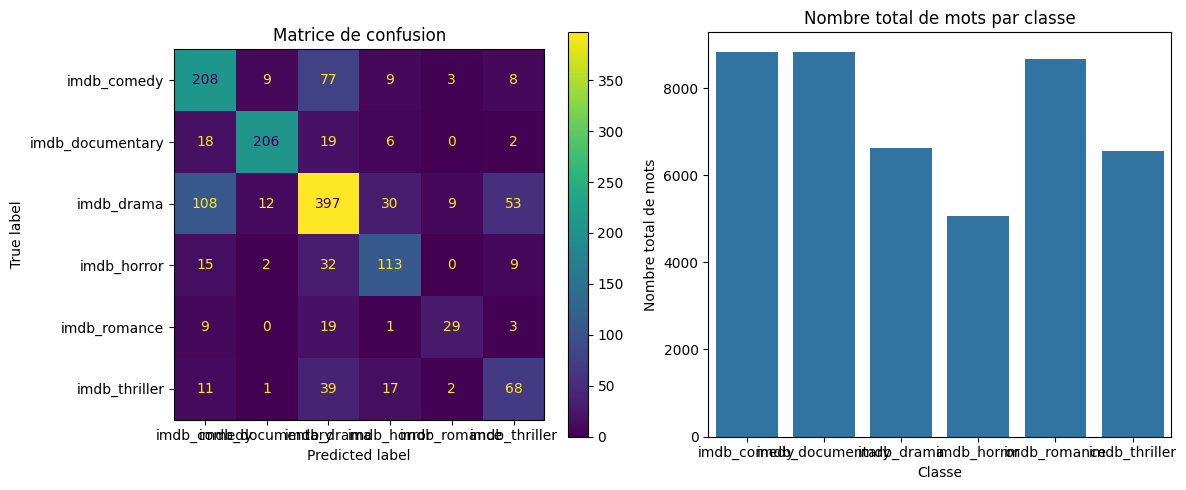

In [25]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), MultinomialNB(alpha=0.08))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigram and laplacian alpha = 0.08")

Model: MultinomialNB with unigram and laplacian alpha = 0.08
Features dimension: (1257, 83272)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.55      0.60      0.57        55
imdb_documentary       0.91      0.88      0.90        60
      imdb_drama       0.55      0.60      0.57        60
     imdb_horror       0.70      0.51      0.59        51
    imdb_romance       0.70      0.76      0.73        42
   imdb_thriller       0.48      0.49      0.48        47

        accuracy                           0.64       315
       macro avg       0.65      0.64      0.64       315
    weighted avg       0.65      0.64      0.65       315

Top 15 mots pour la classe 'imdb_comedy': ['on' 'this' 'my' 'we' 'me' 'in' 'of' 'what' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'this' 'he' 'they' 'we' 'is' 'was' 'in' 'it' 'that' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la clas

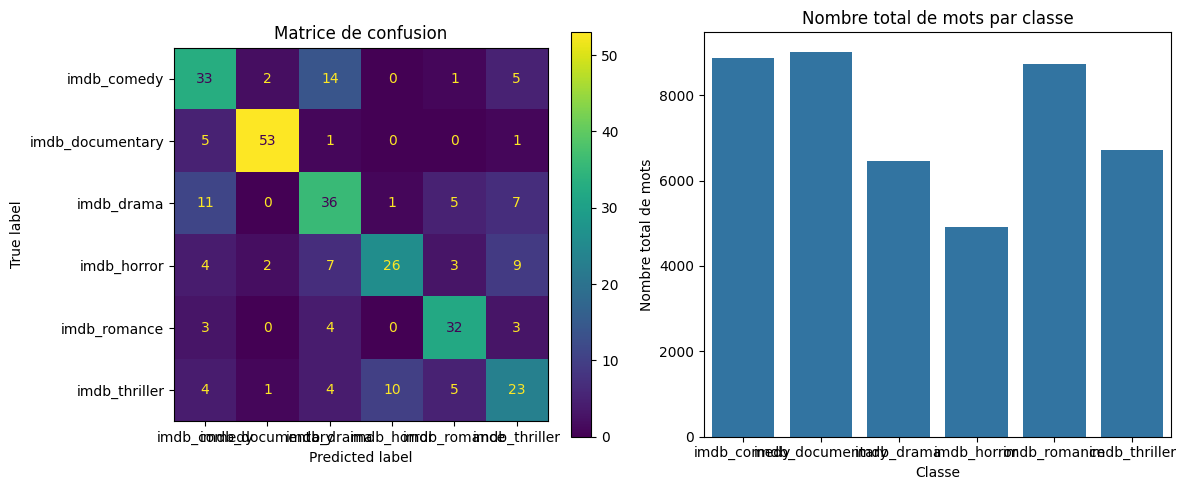

In [26]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), MultinomialNB(alpha=0.08))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="MultinomialNB with unigram and laplacian alpha = 0.08",equilibrate=True)

Model: MultinomialNB with tf idf
Features dimension: (6176, 200664)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.80      0.11      0.20       314
imdb_documentary       0.95      0.55      0.69       251
      imdb_drama       0.45      0.99      0.62       609
     imdb_horror       1.00      0.04      0.08       171
    imdb_romance       0.00      0.00      0.00        61
   imdb_thriller       0.00      0.00      0.00       138

        accuracy                           0.51      1544
       macro avg       0.53      0.28      0.26      1544
    weighted avg       0.60      0.51      0.41      1544



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Top 15 mots pour la classe 'imdb_comedy': ['on' 'this' 'my' 'me' 'we' 'in' 'what' 'is' 'of' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'he' 'they' 'this' 'we' 'was' 'is' 'in' 'that' 'it' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la classe 'imdb_drama': ['for' 'this' 'my' 'we' 'in' 'is' 'of' 'me' 'what' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_horror': ['on' 'no' 'this' 'in' 'is' 'me' 'we' 'of' 'what' 'and' 'that' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_romance': ['my' 'for' 'in' 'this' 'we' 'me' 'of' 'what' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_thriller': ['my' 'no' 'this' 'in' 'we' 'of' 'is' 'me' 'what' 'and' 'that' 'it' 'to'
 'the' 'you']


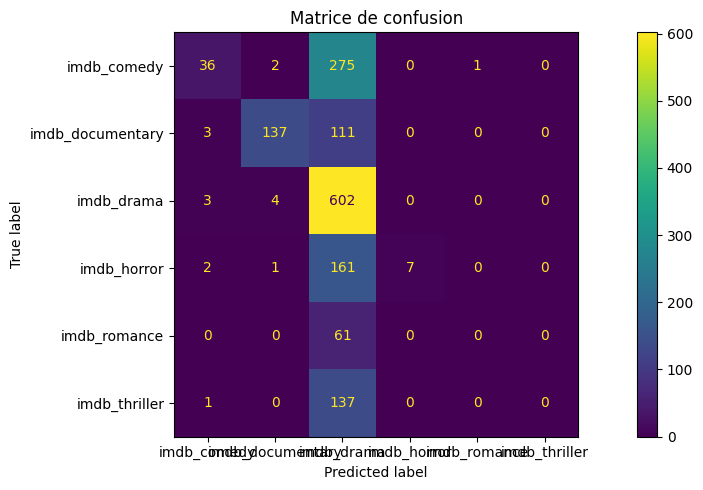

In [27]:
model = make_pipeline(TfidfVectorizer(), MultinomialNB(alpha=0.05))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","top_words"],desc="MultinomialNB with tf idf")

/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Model: MultinomialNB with tf idf
Features dimension: (1257, 81111)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.65      0.58        55
imdb_documentary       0.88      0.82      0.84        60
      imdb_drama       0.50      0.25      0.33        60
     imdb_horror       0.69      0.53      0.60        51
    imdb_romance       0.54      0.88      0.67        42
   imdb_thriller       0.54      0.60      0.57        47

        accuracy                           0.61       315
       macro avg       0.61      0.62      0.60       315
    weighted avg       0.62      0.61      0.60       315

Top 15 mots pour la classe 'imdb_comedy': ['let' 'think' 'gonna' 've' 'good' 'got' 'come' 'll' 'okay' 'right' 'yeah'
 'oh' 'know' 'like' 'don']
Top 15 mots pour la classe 'imdb_documentary': ['good' 'want' 'said' 'yeah' 'got' 'come' 'right' 'going' 've' 'time'
 'think' 'don' 'people' 'know' 'like']
Top 15 mots pour 

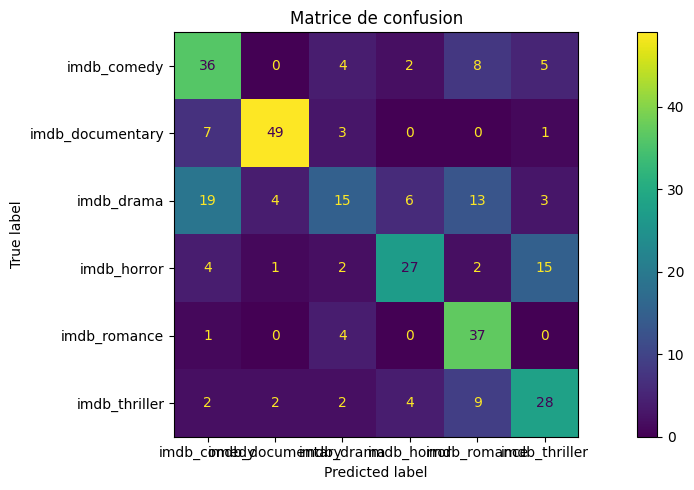

In [28]:
model = make_pipeline(TfidfVectorizer(stop_words=list(en_stop)), MultinomialNB(alpha=0.05))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","top_words"],desc="MultinomialNB with tf idf",equilibrate=True)